## Project Overview

This notebook presents the full analytical workflow behind a residential solar investment analysis, covering data cleaning, financial modeling, and business insights.

**Tools Used:** Python (Pandas, NumPy), SQL, Statistical Analysis, Data Cleaning

For a concise business-oriented summary, see:
👉 solar_analysis_summary.pdf

**Key Highlights:**
- Profitable investment with recurring winter liquidity risk  
- Panel cleaning shows ~148% ROI, based on a single observed event  
- Solar radiation does not consistently translate to revenue (efficiency gaps)  
- Significant wealth is generated post loan maturity (Dec 2034)

## Data Loading & Initial Setup

In [59]:


import pandas as pd
import sqlite3
import os

# --- DATABASE CONNECTION ---
conn = sqlite3.connect('solar_project.db')
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

required_columns = ['תאריך ערך', 'סכום', 'מע"מ']

for file_name in csv_files:
    temp_df = pd.read_csv(file_name, nrows=0)
    temp_df.columns = temp_df.columns.str.strip()

    if all(col in temp_df.columns for col in required_columns):
        print(f"Processing: {file_name}") # Professional logging

        df = pd.read_csv(file_name)
        df.columns = df.columns.str.strip()

        # Feature Engineering: Date conversion & Net revenue calculation
        df['payment_date'] = pd.to_datetime(df['תאריך ערך'], dayfirst=True)
        df['net_amount'] = df['סכום'] - df['מע"מ']

        # Selecting final columns for database storage
        final_cols = required_columns + ['payment_date', 'net_amount']
        df_to_save = df[final_cols]

        # Storing data to SQLite - Using 'replace' to ensure clean schema
        df_to_save.to_sql('incomes', conn, if_exists='replace', index=False)
    else:
        print(f"Skipping {file_name}: Incomplete Schema")

print("\nETL Pipeline Completed Successfully.")

Processing: תשלומי חשמל.csv

ETL Pipeline Completed Successfully.


## Data Integration – Maintenance & Loan Tables

In [60]:


conn = sqlite3.connect('solar_project.db')

# 1. Loan Liability Configuration
loan_data = pd.DataFrame({
    'loan_balance': [437214.0],
    'monthly_repayment': [5418.0],
    'end_date': ['2034-12-30']
})
loan_data['end_date'] = pd.to_datetime(loan_data['end_date'])
loan_data.to_sql('loan_details', conn, if_exists='replace', index=False)

# 2. Maintenance & Operations (O&M) Records
maintenance_data = pd.DataFrame({
    'cleaning_date': ['2025-05-15'],
    'cost_total': [1170.0]  # Total cash outflow including VAT
})
maintenance_data['cleaning_date'] = pd.to_datetime(maintenance_data['cleaning_date'])
maintenance_data.to_sql('maintenance', conn, if_exists='replace', index=False)

print("Reference tables (Loan & Maintenance) successfully updated in SQL.")

Reference tables (Loan & Maintenance) successfully updated in SQL.


## Data Validation & Integrity Checks

In [61]:
conn = sqlite3.connect('solar_project.db')

# Inspecting the SQLite Master table to list all existing tables
check_query = "SELECT name FROM sqlite_master WHERE type='table';"
existing_tables = pd.read_sql(check_query, conn)

print("--- Database Schema Verification ---")
if not existing_tables.empty:
    print(f"Successfully verified {len(existing_tables)} tables:")
    print(existing_tables)
else:
    print(" Warning: No tables found in the database.")

--- Database Schema Verification ---
Successfully verified 3 tables:
           name
0       incomes
1  loan_details
2   maintenance


## Initial Data Exploration & Consistency Checks

### Record Count Mismatch

The dataset contains 50 records instead of the expected 49 monthly observations based on the project timeline.

**Key Insight:** This discrepancy indicates potential data quality issues such as duplicate or misaligned records, which must be resolved before performing financial analysis.

In [62]:


conn = sqlite3.connect('solar_project.db')

stats_query = """
SELECT
    COUNT(net_amount) AS total_months,
    ROUND(AVG(net_amount), 0) AS avg_monthly_income,
    ROUND(MIN(net_amount), 0) AS min_monthly_income,
    ROUND(MAX(net_amount), 0) AS max_monthly_income,
    ROUND(SUM(net_amount), 0) AS total_cumulative_income
FROM incomes;
"""

stats_df = pd.read_sql(stats_query, conn)
display(stats_df)
# Logically, 4 years and 1 month should total 49 records. The presence of 50 records suggests a data anomal

,total_months,avg_monthly_income,min_monthly_income,max_monthly_income,total_cumulative_income
0,50,8048.0,3551.0,13489.0,402412.0


## Yearly Data Consistency Analysis

### Incomplete Yearly Coverage

Initial exploration shows that some years do not contain the expected 12 monthly records.

**Key Insight:** Missing monthly data can distort year-over-year comparisons and lead to misleading conclusions if not properly addressed.

In [63]:
# Grouping data by year to identify specific recording errors
yearly_stats_query = """
SELECT
    strftime('%Y', payment_date) AS year,
    COUNT(net_amount) AS months_active,
    ROUND(AVG(net_amount), 0) AS avg_monthly_income
FROM incomes
GROUP BY year
ORDER BY year ASC;
"""

yearly_df = pd.read_sql(yearly_stats_query, conn)

# Logically highlighting the findings
print("--- Annual Data Integrity Check ---")
display(yearly_df)

# Note: This analysis confirms that 2023 has an extra record (13)
# and 2025 is missing one (11) while 2026 is extra one

--- Annual Data Integrity Check ---


,year,months_active,avg_monthly_income
0,2022,12,7829.0
1,2023,13,8393.0
2,2024,12,8005.0
3,2025,11,8564.0
4,2026,2,4546.0


## Data Cleaning & Preprocessing

This section prepares the dataset for analysis by correcting data quality issues such as billing lag, duplicate invoices, and anomalies.

In [64]:
import sqlite3
import pandas as pd

# 1. Database Connection
conn = sqlite3.connect('solar_project.db')
cursor = conn.cursor()

# 2. Define Cleaning Logic (SQL)
# Rule A: Deduplication using unique rowid
sql_remove_duplicates = """
DELETE FROM incomes
WHERE rowid NOT IN (
    SELECT MIN(rowid)
    FROM incomes
    GROUP BY payment_date, net_amount
);
"""

# Rule B: Temporal Alignment (Early-month payments shifted to previous month)
sql_fix_dates = """
UPDATE incomes
SET payment_date = date(payment_date, 'start of month', '-1 day')
WHERE strftime('%d', payment_date) <= '05';
"""

# 3. Execution & Transaction Management
try:
    # Execute cleaning steps
    cursor.execute(sql_remove_duplicates)
    deleted_count = cursor.rowcount

    cursor.execute(sql_fix_dates)
    updated_count = cursor.rowcount

    conn.commit()
    print(f"✓ Data Cleaning Successful: {deleted_count} duplicates removed, {updated_count} dates re-aligned.")

    # 4. Automated Quality Assurance (QA) - Sanity Checks
    # Check for negative values or extreme outliers (less than 10% of global average)
    avg_val_query = "SELECT AVG(net_amount) FROM incomes"
    cursor.execute(avg_val_query)
    global_avg = cursor.fetchone()[0] or 0
    threshold = global_avg * 0.1

    qa_query = f"""
    SELECT payment_date, net_amount
    FROM incomes
    WHERE net_amount <= 0 OR net_amount < {threshold}
    """
    qa_issues = pd.read_sql(qa_query, conn)

    print("\n--- QA Report ---")
    if qa_issues.empty:
        print(f"✅ Sanity Check Passed: No negative values or extreme outliers (threshold: {threshold:.0f} ILS).")
    else:
        print(f"⚠️ Warning: Found {len(qa_issues)} potential data anomalies:")
        print(qa_issues)

except Exception as e:
    print(f"✗ Error during sanitization: {e}")
    conn.rollback()
finally:
    cursor.close()

✓ Data Cleaning Successful: 1 duplicates removed, 1 dates re-aligned.

--- QA Report ---
✅ Sanity Check Passed: No negative values or extreme outliers (threshold: 798 ILS).


## Revenue Analysis by Year

This section analyzes revenue trends across years to identify performance patterns.

In [65]:
# Final validation query to ensure 12-month consistency across all years
validation_query = """
SELECT
    strftime('%Y', payment_date) AS year,
    COUNT(*) AS months_active,
    ROUND(AVG(net_amount), 0) AS avg_monthly_income,
    ROUND(SUM(net_amount), 0) AS total_yearly_income
FROM incomes
GROUP BY year
ORDER BY year ASC;
"""

validation_df = pd.read_sql(validation_query, conn)

print("--- Final Data Integrity Report ---")
display(validation_df)

# Logic check: Ensuring total count is now 49 (or the expected count)
total_records = validation_df['months_active'].sum()
print(f"\nVerification Complete: Total records aligned at {total_records} months.")

--- Final Data Integrity Report ---


,year,months_active,avg_monthly_income,total_yearly_income
0,2022,12,7829.0,93949.0
1,2023,12,8150.0,97803.0
2,2024,12,8005.0,96055.0
3,2025,12,8239.0,98867.0
4,2026,1,4432.0,4432.0



Verification Complete: Total records aligned at 49 months.


## Net Profit & Cash Flow Analysis

This section evaluates whether the solar asset generates positive cash flow after loan repayments and identifies periods of financial stress.

In [66]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('solar_project.db')


repayment_amount = pd.read_sql("SELECT monthly_repayment FROM loan_details", conn).iloc[0,0]


seasonality_query = f"""
SELECT
    strftime('%m', payment_date) AS month,
    ROUND(AVG(net_amount), 0) AS avg_income,
    ROUND(AVG(net_amount) - {repayment_amount}, 0) AS avg_cash_flow,
    COUNT(*) AS sample_size
FROM incomes
GROUP BY month
ORDER BY month ASC;
"""

seasonality_df = pd.read_sql(seasonality_query, conn)


numeric_cols = ['avg_income', 'avg_cash_flow']
seasonality_df[numeric_cols] = seasonality_df[numeric_cols].astype(int)

print(f"--- Monthly Seasonality Profile (Loan Repayment: {int(repayment_amount):,} ILS) ---")


display(seasonality_df.style.hide(axis='index'))
#the results of september suprised me.

--- Monthly Seasonality Profile (Loan Repayment: 5,418 ILS) ---


month,avg_income,avg_cash_flow,sample_size
01,4193,-1225,5
02,4970,-448,4
03,6102,684,4
04,8434,3016,4
05,9645,4227,4
06,11660,6242,4
07,11647,6229,4
08,10694,5276,4
09,8929,3511,4
10,10216,4798,4


## Monthly Financial Stability Analysis

This section evaluates the stability and variability of monthly income relative to fixed loan obligations.

In [67]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('solar_project.db')

# Dynamic retrieval of loan repayment from reference table
repayment_amount = pd.read_sql("SELECT monthly_repayment FROM loan_details", conn).iloc[0,0]

# Extracting raw income data for statistical processing
df_raw = pd.read_sql("SELECT strftime('%m', payment_date) as month, net_amount FROM incomes", conn)

# Calculating core metrics: Mean, Standard Deviation, and Sample Size
monthly_stats = df_raw.groupby('month')['net_amount'].agg(['count', 'mean', 'std']).reset_index()

# Engineering financial stability metrics
monthly_stats['avg_cash_flow'] = monthly_stats['mean'] - repayment_amount
monthly_stats['cv_percent'] = (monthly_stats['std'] / monthly_stats['mean']) * 100

# Formatting column names for professional reporting
monthly_stats.columns = ['Month', 'Records', 'Avg Income', 'Std Dev', 'Avg Cash Flow', 'CV (%)']

# Final data cleaning: removing decimals and hiding index
monthly_stats = monthly_stats.round(0).astype({
    'Avg Income': int,
    'Std Dev': int,
    'Avg Cash Flow': int,
    'CV (%)': float
})

print(f"--- Monthly Statistical Stability (Reference Repayment: {int(repayment_amount):,} ILS) ---")
display(monthly_stats.style.hide(axis='index'))
# Insight: September displays an average CV of 13%, indicating that the
# revenue dip is a stable seasonal trend rather than a result of
# volatile anomalies or data errors.

--- Monthly Statistical Stability (Reference Repayment: 5,418 ILS) ---


Month,Records,Avg Income,Std Dev,Avg Cash Flow,CV (%)
01,5,4193,376,-1225,9.000000
02,4,4970,622,-448,13.000000
03,4,6102,955,684,16.000000
04,4,8434,747,3016,9.000000
05,4,9645,602,4227,6.000000
06,4,11660,897,6242,8.000000
07,4,11647,1234,6229,11.000000
08,4,10694,2112,5276,20.000000
09,4,8929,1119,3511,13.000000
10,4,10216,1276,4798,12.000000


## Solar Efficiency Analysis: Revenue vs Radiation

This section evaluates the relationship between solar radiation and revenue to identify efficiency gaps.

In [68]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('solar_project.db')

# Solar radiation averages (kWh/m²) based on regional meteorological data
monthly_rad_map = {
    '01': 80.6,  '02': 95.2,  '03': 148.8, '04': 186.0,
    '05': 226.3, '06': 243.0, '07': 244.9, '08': 220.1,
    '09': 177.0, '10': 136.4, '11': 96.0,  '12': 74.4
}

# Fetching average monthly income from database
query = """
SELECT
    strftime('%m', payment_date) AS Month,
    AVG(net_amount) AS Avg_Income
FROM incomes
GROUP BY Month
"""

df = pd.read_sql(query, conn)

# Feature Engineering: Mapping radiation and calculating the Efficiency Index
df['Radiation'] = df['Month'].map(monthly_rad_map)
df['Efficiency_Index'] = df['Avg_Income'] / df['Radiation']

# Sorting by index to identify top-performing months relative to radiation
result_df = df.sort_values(by='Efficiency_Index', ascending=False)

# Final cleanup: rounding to integers for clean presentation (except for the index)
result_df['Avg_Income'] = result_df['Avg_Income'].round(0).astype(int)
result_df['Radiation'] = result_df['Radiation'].round(0).astype(int)

print("--- System Efficiency Analysis (Revenue per Radiation Unit) ---")
display(result_df.style.format({'Efficiency_Index': '{:.2f}'}).hide(axis='index'))

--- System Efficiency Analysis (Revenue per Radiation Unit) ---


Month,Avg_Income,Radiation,Efficiency_Index
10,10216,136,74.89
12,4654,74,62.56
11,5586,96,58.19
02,4970,95,52.20
01,4193,81,52.02
09,8929,177,50.44
08,10694,220,48.59
06,11660,243,47.98
07,11647,245,47.56
04,8434,186,45.34


## Paired T-Test: September vs October Revenue

This section evaluates whether the difference in revenue between September and October is statistically significant using a paired t-test.

In [69]:
import pandas as pd
import sqlite3
from scipy import stats

conn = sqlite3.connect('solar_project.db')

# Extracting paired monthly data for comparative analysis
query = """
SELECT
    strftime('%Y', payment_date) AS Year,
    strftime('%m', payment_date) AS Month,
    net_amount AS Income
FROM incomes
WHERE Month IN ('09', '10')
"""
df = pd.read_sql(query, conn)

# Aligning September and October results by year
pivot_df = df.pivot(index='Year', columns='Month', values='Income').dropna()
sep, oct_data = pivot_df['09'], pivot_df['10']

# Executing Paired T-Test
t_stat, p_val = stats.ttest_rel(oct_data, sep)
mean_diff = (oct_data - sep).mean()

print("--- Statistical Hypothesis Testing ---")
print(f"Mean Difference (Oct-Sep): {int(mean_diff):,} ILS")
print(f"P-Value: {p_val:.4f}")

# Insight: P-Value > 0.05 is expected for n=4 due to low statistical power.
# The consistent directional trend aligns with the solar radiation data
# previously analyzed, confirming a stable seasonal pattern.

--- Statistical Hypothesis Testing ---
Mean Difference (Oct-Sep): 1,286 ILS
P-Value: 0.3486


## Maintenance Impact on Profitability

This section analyzes the financial impact of panel cleaning by comparing performance before and after the maintenance event.

In [70]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('solar_project.db')

# 1. Dynamically retrieve the latest cleaning event
maint_query = "SELECT cleaning_date, cost_total FROM maintenance ORDER BY cleaning_date DESC LIMIT 1"
latest_maint = pd.read_sql(maint_query, conn).iloc[0]

cleaning_date = latest_maint['cleaning_date']
total_cost = latest_maint['cost_total']

# 2. Historical Baseline (Excluding the year of cleaning to avoid bias)
baseline_query = f"""
SELECT
    strftime('%m', payment_date) as Month,
    AVG(net_amount) as Historical_Avg
FROM incomes
WHERE strftime('%Y', payment_date) < strftime('%Y', '{cleaning_date}')
GROUP BY Month
"""
df_baseline = pd.read_sql(baseline_query, conn)

# 3. Post-Cleaning Performance
# Using '+2 months' from the first of the cleaning month to start from July
actual_query = f"""
SELECT
    strftime('%Y-%m', payment_date) as Period,
    strftime('%m', payment_date) as Month,
    net_amount as Actual_Income
FROM incomes
WHERE payment_date >= date('{cleaning_date}', 'start of month', '+2 months')
ORDER BY Period
"""
df_actual = pd.read_sql(actual_query, conn)

# 4. Impact Calculation
df_final = pd.merge(df_actual, df_baseline, on='Month')
df_final['Added_Value'] = df_final['Actual_Income'] - df_final['Historical_Avg']
df_final['Cumulative_Gain'] = df_final['Added_Value'].cumsum()

# Aggregating final metrics
total_gain = df_final['Added_Value'].sum()
roi_pct = (total_gain / total_cost) * 100
net_profit = total_gain - total_cost

# 5. Professional Display
numeric_cols = ['Actual_Income', 'Historical_Avg', 'Added_Value', 'Cumulative_Gain']
df_display = df_final.copy()
df_display[numeric_cols] = df_display[numeric_cols].round(0).astype(int)

print(f"--- ROI Analysis: Impact since Cleaning ({cleaning_date}) ---")
print(f"Investment Cost: {int(total_cost):,} ILS")
display(df_display.style.hide(axis='index'))

print(f"\nFinal Statistics (as of {df_final['Period'].max()}):")
print(f"Total Gain to Date: {int(total_gain):,} ILS")
print(f"Net Profit: {int(net_profit):,} ILS")
print(f"Current ROI: {roi_pct:.1f}%")

--- ROI Analysis: Impact since Cleaning (2025-05-15 00:00:00) ---
Investment Cost: 1,170 ILS


Period,Month,Actual_Income,Historical_Avg,Added_Value,Cumulative_Gain
2025-07,07,11196,11797,-601,-601
2025-08,08,12168,10203,1965,1364
2025-09,09,9536,8726,809,2174
2025-10,10,10260,10201,59,2233
2025-11,11,5767,5526,241,2474
2025-12,12,4660,4652,8,2481
2026-01,01,4432,4013,419,2900



Final Statistics (as of 2026-01):
Total Gain to Date: 2,899 ILS
Net Profit: 1,729 ILS
Current ROI: 247.9%


## Revenue Allocation: Owner vs Debt Repayment

This section illustrates how monthly revenue is distributed between the asset owner and loan repayment.

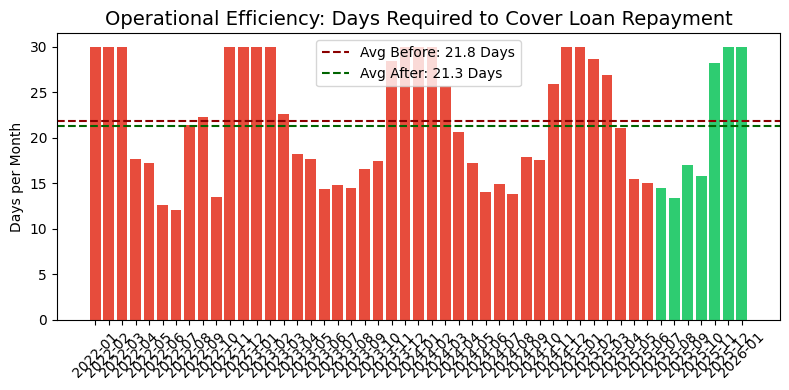

--- Operational Impact Report ---
Efficiency Gain: The system now works 0.5 fewer days for the bank every month.


In [71]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect('solar_project.db')

# 1. Data Retrieval
maintenance_df = pd.read_sql("SELECT cleaning_date FROM maintenance WHERE cost_total > 0 ORDER BY cleaning_date ASC", conn)
raw_data = pd.read_sql("""
    SELECT
        strftime('%Y-%m', payment_date) as billing_month,
        net_amount as monthly_income,
        (SELECT monthly_repayment FROM loan_details LIMIT 1) as loan_repayment
    FROM incomes
    ORDER BY billing_month
""", conn)

# 2. Metric Engineering: Days required to cover debt
raw_data['days_for_bank'] = (raw_data['loan_repayment'] / raw_data['monthly_income']) * 30
raw_data['days_for_bank'] = raw_data['days_for_bank'].clip(upper=30)

# 3. Period Tagging (Implementing the 2-month reporting lag)
def label_period(row_month, maintenance_dates):
    first_cleaning = pd.to_datetime(maintenance_dates.iloc[0]['cleaning_date'])
    effective_start = (first_cleaning + pd.DateOffset(months=2)).strftime('%Y-%m')
    return 'Pre-Maintenance' if row_month < effective_start else 'Post-Maintenance Efficiency'

raw_data['period_status'] = raw_data['billing_month'].apply(lambda x: label_period(x, maintenance_df))

# 4. Professional Visualization
plt.figure(figsize=(8, 4))
colors = raw_data['period_status'].map({'Pre-Maintenance': '#e74c3c', 'Post-Maintenance Efficiency': '#2ecc71'})

plt.bar(raw_data['billing_month'], raw_data['days_for_bank'], color=colors)

# Group averages for benchmarking
pre_mean = raw_data[raw_data['period_status'] == 'Pre-Maintenance']['days_for_bank'].mean()
post_mean = raw_data[raw_data['period_status'] == 'Post-Maintenance Efficiency']['days_for_bank'].mean()

plt.axhline(y=pre_mean, color='darkred', linestyle='--', label=f'Avg Before: {pre_mean:.1f} Days')
plt.axhline(y=post_mean, color='darkgreen', linestyle='--', label=f'Avg After: {post_mean:.1f} Days')

plt.title('Operational Efficiency: Days Required to Cover Loan Repayment', fontsize=14)
plt.ylabel('Days per Month')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Strategic Summary
print(f"--- Operational Impact Report ---")
print(f"Efficiency Gain: The system now works {pre_mean - post_mean:.1f} fewer days for the bank every month.")

## Financial Summary Snapshot

In [72]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('solar_project.db')

# 1. Aggregate revenue and periods from database
income_query = "SELECT SUM(net_amount) as total_gross, COUNT(*) as billing_months FROM incomes"
df_income = pd.read_sql(income_query, conn)

# 2. Retrieve loan parameters
df_loan = pd.read_sql("SELECT monthly_repayment FROM loan_details LIMIT 1", conn)

# 3. Financial Calculations
recorded_gross = df_income['total_gross'].iloc[0]
months_recorded = df_income['billing_months'].iloc[0]
monthly_repayment = df_loan['monthly_repayment'].iloc[0]

# Total debt service for the period where revenue is tracked
total_debt_service = months_recorded * monthly_repayment
net_cash_flow = recorded_gross - total_debt_service
profit_margin = (net_cash_flow / recorded_gross) * 100

# 4. Professional Reporting
print(f"--- Cumulative Financial Health (Aligned Period: {months_recorded} Months) ---")
print(f"Recorded Gross Revenue   : {int(recorded_gross):>10,} ILS")
print(f"Debt Service (Aligned)   : {int(total_debt_service):>10,} ILS")
print(f"--------------------------------------------------")
print(f"Free Cash Flow (FCF)     : {int(net_cash_flow):>10,} ILS")
print(f"Cash-on-Cash Margin      : {profit_margin:>10.2f}%")

# 5. Strategic Note regarding 2021 data
print(f"\n* Note: This summary is conservative.")
print(f"  Actual cumulative profit is higher, as revenue from 2021 is not yet recorded,")
print(f"  while the loan service has been consistent since project inception.")

--- Cumulative Financial Health (Aligned Period: 49 Months) ---
Recorded Gross Revenue   :    391,105 ILS
Debt Service (Aligned)   :    265,482 ILS
--------------------------------------------------
Free Cash Flow (FCF)     :    125,623 ILS
Cash-on-Cash Margin      :      32.12%

* Note: This summary is conservative.
  Actual cumulative profit is higher, as revenue from 2021 is not yet recorded,
  while the loan service has been consistent since project inception.


## Leveraged Wealth Creation & Ownership Analysis  

This section evaluates how equity and total wealth are accumulated over time through leveraged investment.

In [73]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('solar_project.db')

# 1. Financial Constants (Project Foundation)
ORIGINAL_LOAN = 736000
CURRENT_BALANCE = 437214

# 2. Performance & Loan Retrieval
income_query = """
    SELECT
        SUM(net_amount) as total_gross,
        COUNT(*) as months
    FROM incomes
"""
df_finance = pd.read_sql(income_query, conn)
df_loan_meta = pd.read_sql("SELECT monthly_repayment FROM loan_details LIMIT 1", conn)

# 3. Core Financial Calculations
total_gross = df_finance['total_gross'].iloc[0]
months = df_finance['months'].iloc[0]
monthly_pay = df_loan_meta['monthly_repayment'].iloc[0]

# Cash Profit (Liquidity)
total_paid_to_bank = months * monthly_pay
net_cash_profit = total_gross - total_paid_to_bank

# Equity & Wealth (Asset Value)
principal_repaid = ORIGINAL_LOAN - CURRENT_BALANCE
equity_percent = (principal_repaid / ORIGINAL_LOAN) * 100
total_wealth = net_cash_profit + principal_repaid

# 4. Professional Reporting Summary
print(f"--- Asset Ownership & Wealth Strategy ---")
print(f"Original Project Cost  : {int(ORIGINAL_LOAN):>10,} ILS")
print(f"Current Loan Balance   : {int(CURRENT_BALANCE):>10,} ILS")
print(f"Equity (Ownership)     : {equity_percent:>10.1f}%")
print(f"------------------------------------------")
print(f"Cumulative Cash Profit : {int(net_cash_profit):>10,} ILS")
print(f"Principal Repaid       : {int(principal_repaid):>10,} ILS")
print(f"------------------------------------------")
print(f"TOTAL WEALTH GENERATED : {int(total_wealth):>10,} ILS")
#total wealth probably higher,we dont have data for 2021

--- Asset Ownership & Wealth Strategy ---
Original Project Cost  :    736,000 ILS
Current Loan Balance   :    437,214 ILS
Equity (Ownership)     :       40.6%
------------------------------------------
Cumulative Cash Profit :    125,623 ILS
Principal Repaid       :    298,786 ILS
------------------------------------------
TOTAL WEALTH GENERATED :    424,409 ILS


## Solar Asset Lifecycle: ROI & Wealth Accumulation Strategy

This section presents the full financial lifecycle of the asset, including break-even, ROI progression, and long-term wealth generation.

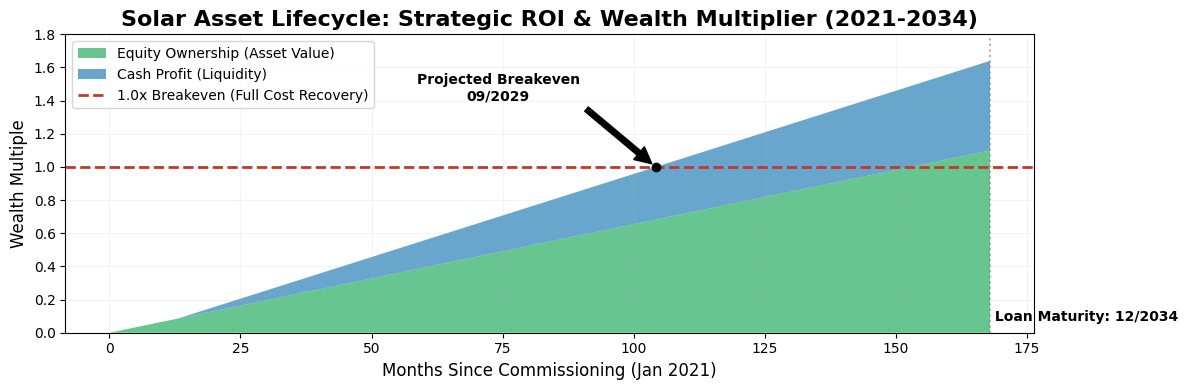


          EXECUTIVE FINANCIAL SUMMARY: SOLAR ASSET          
Annualized Cash Yield (Liquid)      |       30,765 ILS
Annualized Equity Growth (Asset)    |       57,830 ILS
------------------------------------------------------------
TOTAL ANNUAL WEALTH VELOCITY        |       88,595 ILS
CURRENT RECOVERY PROGRESS           |        57.7%
ESTIMATED FULL RECOVERY (1.0x)      |      09/2029
LOAN MATURITY DATE                  |      12/2034



In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

# =================================================================
# 1. PROJECT PARAMETERS (Verified Benchmarks)
# =================================================================
ORIGINAL_COST = 736000
CURRENT_BALANCE = 437214
CASH_PROFIT_ACCUMULATED = 125623.94

# Temporal Benchmarks
START_DATE = datetime(2021, 1, 1)
MONTHS_SINCE_START = 62      # As of Feb 2026
MONTHS_WITH_DATA = 49        # Documented production months
TOTAL_LOAN_TERM = 168        # 14-Year Tenure (Jan 2021 - Dec 2034)

# =================================================================
# 2. WEALTH VELOCITY & PROJECTION LOGIC
# =================================================================
# A. Equity & Cash Yield Rates (Monthly)
principal_repaid = ORIGINAL_COST - CURRENT_BALANCE
monthly_equity_gain = principal_repaid / MONTHS_SINCE_START
monthly_cash_yield = CASH_PROFIT_ACCUMULATED / MONTHS_WITH_DATA

# B. Dynamic Breakeven Calculation
current_total_wealth = principal_repaid + CASH_PROFIT_ACCUMULATED
remaining_to_recover = ORIGINAL_COST - current_total_wealth
total_monthly_velocity = monthly_equity_gain + monthly_cash_yield

# Months from today until full cost recovery
months_to_breakeven = remaining_to_recover / total_monthly_velocity
breakeven_month_index = MONTHS_SINCE_START + months_to_breakeven

# C. Generating Dynamic Date for Output
breakeven_date_obj = START_DATE + pd.DateOffset(months=int(breakeven_month_index))
breakeven_date_str = breakeven_date_obj.strftime('%m/%Y')

# =================================================================
# 3. STRATEGIC VISUALIZATION
# =================================================================
timeline = np.arange(TOTAL_LOAN_TERM + 1)
equity_projection = (monthly_equity_gain * timeline) / ORIGINAL_COST
cash_projection = (monthly_cash_yield * np.maximum(0, timeline - (MONTHS_SINCE_START - MONTHS_WITH_DATA))) / ORIGINAL_COST

plt.figure(figsize=(12, 4))

# Stackplot showing cumulative wealth components
plt.stackplot(timeline, equity_projection, cash_projection,
              labels=['Equity Ownership (Asset Value)', 'Cash Profit (Liquidity)'],
              colors=['#27ae60', '#2980b9'], alpha=0.7)

# Strategic Milestone: 1.0x Full Cost Recovery
plt.axhline(y=1.0, color='#c0392b', linestyle='--', linewidth=2, label='1.0x Breakeven (Full Cost Recovery)')
plt.scatter(breakeven_month_index, 1.0, color='black', zorder=5)

# Forecast Annotation
plt.annotate(f'Projected Breakeven\n{breakeven_date_str}',
             xy=(breakeven_month_index, 1.0),
             xytext=(breakeven_month_index-30, 1.4),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontweight='bold', ha='center')

# Loan Maturity Marker
plt.axvline(x=TOTAL_LOAN_TERM, color='gray', linestyle=':', alpha=0.6)
plt.text(TOTAL_LOAN_TERM, 0.05, f' Loan Maturity: 12/2034', verticalalignment='bottom', fontweight='bold')

# Styling
plt.title('Solar Asset Lifecycle: Strategic ROI & Wealth Multiplier (2021-2034)', fontsize=16, fontweight='bold')
plt.xlabel('Months Since Commissioning (Jan 2021)', fontsize=12)
plt.ylabel('Wealth Multiple'.format(current_total_wealth/ORIGINAL_COST), fontsize=12)
plt.legend(loc='upper left')
plt.grid(alpha=0.15)
plt.ylim(0, 1.8)
plt.tight_layout()
plt.show()

# =================================================================
# 4. EXECUTIVE SUMMARY (Fully Automated)
# =================================================================
print(f"\n{'='*60}")
print(f"{'EXECUTIVE FINANCIAL SUMMARY: SOLAR ASSET':^60}")
print(f"{'='*60}")
print(f"{'Annualized Cash Yield (Liquid)':<35} | {monthly_cash_yield * 12:>12,.0f} ILS")
print(f"{'Annualized Equity Growth (Asset)':<35} | {monthly_equity_gain * 12:>12,.0f} ILS")
print(f"{'-'*60}")
print(f"{'TOTAL ANNUAL WEALTH VELOCITY':<35} | {total_monthly_velocity * 12:>12,.0f} ILS")
print(f"{'='*60}")
print(f"{'CURRENT RECOVERY PROGRESS':<35} | {(current_total_wealth/ORIGINAL_COST)*100:>11.1f}%")
print(f"{'ESTIMATED FULL RECOVERY (1.0x)':<35} | {breakeven_date_str:>12}")
print(f"{'LOAN MATURITY DATE':<35} | {'12/2034':>12}")
print(f"{'='*60}\n")

**Final Insight:** The investment generates value through both ongoing cash flow and increasing equity ownership, with long-term wealth driven by the combination of income generation and loan repayment.

## Future Improvements

- Incorporating panel degradation effects over time  
- Enhancing weather sensitivity analysis using external data  
- Validating maintenance impact with additional observations  